<!-- ========================= -->
<!--  House Price Analysis    -->
<!-- ========================= -->

<h1 style="text-align:center; font-size:3rem; color:#2c3e50;">
🏠 House Price Analysis
</h1>

<h3 style="text-align:center; color:#34495e;">
Exploring Apartment Listings in Tirana
</h3>

In [25]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib 
import os
from typing import Dict, List, Tuple
from math import radians, sin, cos, sqrt, atan2

# Visualization Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_colwidth', None)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


<hr style="border:1px solid #ddd;"> <h2 style="color:#2c3e50;">📌 The Problem</h2> <p style="font-size:15px; line-height:1.6;"> Real estate markets are influenced by many factors such as <b>location</b>, <b>apartment size</b>, <b>floor level</b>, <b>number of rooms</b>, <b>furnishing status</b>, and various amenities. Understanding how these variables affect apartment prices is essential for <b>buyers</b>, <b>sellers</b>, and <b>real estate agents</b>. </p> <p style="font-size:15px; line-height:1.6;"> In this project, we analyze a <b>JSON dataset</b> containing apartment listings, primarily located in <b>Tirana, Albania</b>. Each listing provides the following information: </p> <ul style="font-size:15px;"> <li>💶 <b>Price</b> (in EUR)</li> <li>📐 <b>Surface area</b> (square meters)</li> <li>🛏️ <b>Number of rooms</b> (bedrooms, bathrooms, living rooms, balconies)</li> <li>🏢 <b>Floor level</b></li> <li>🛋️ <b>Furnishing status</b></li> <li>📍 <b>Location</b> (address and coordinates)</li> </ul> <hr style="border:1px solid #ddd;"> <h2 style="color:#2c3e50;">

In [26]:
# Load data from JSON file
df = pd.read_json("house_price.json")

print("DATASET OVERVIEW")
print(f"Number of listings (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

print("\nColumn names (raw):")
print(df.columns.tolist())

# Preview first 2 rows
df.head(2)

DATASET OVERVIEW
Number of listings (rows): 4505
Number of features (columns): 24

Column names (raw):
['main_property_description_text_content_original_text', 'main_property_floor', 'main_property_furnishing_status', 'main_property_has_carport', 'main_property_has_elevator', 'main_property_has_garage', 'main_property_has_garden', 'main_property_has_parking_space', 'main_property_has_terrace', 'main_property_location_city_zone_city_city_name', 'main_property_location_city_zone_formatted_address', 'main_property_location_lat', 'main_property_location_lng', 'main_property_price', 'main_property_price_currency', 'main_property_property_composition_balconies', 'main_property_property_composition_bathrooms', 'main_property_property_composition_bedrooms', 'main_property_property_composition_kitchens', 'main_property_property_composition_living_rooms', 'main_property_property_status', 'main_property_property_type', 'price_in_euro', 'main_property_property_square']


,main_property_description_text_content_original_text,main_property_floor,main_property_furnishing_status,main_property_has_carport,main_property_has_elevator,main_property_has_garage,main_property_has_garden,main_property_has_parking_space,main_property_has_terrace,main_property_location_city_zone_city_city_name,...,main_property_price_currency,main_property_property_composition_balconies,main_property_property_composition_bathrooms,main_property_property_composition_bedrooms,main_property_property_composition_kitchens,main_property_property_composition_living_rooms,main_property_property_status,main_property_property_type,price_in_euro,main_property_property_square
0,"| Përshkrimi i apartamentit:\n\n♦Sallon i bollshëm me kuzhinë të hapur\n\n♦3 dhoma gjumi\n\n♦2 tualete\n\n♦Verandë\n\n| Apartamenti është investuar në detaje, me mobilim modern, Përfshin gjithashtu një oxhak dhe të gjitha elektroshtepiaket e nevojshme, përfshirë tharesen e rrobave.\n\n♦Detaje shtesë:\n\n♦Sipërfaqe e brendshme: 205 m²\n\n♦Kati: 2 -të\n\n♦Pallat i ri, me ashensor.\n\n♦Cmimi: 400,000€\n\n| Ky apartament është një mundësi e shkëlqyer për ata që kërkojnë të jetojnë në një zonë të zhvilluar dhe të sigurt, me qasje të lehtë në infrastrukturën kryesore të qytetit.\n\n♦Për më shumë informacion dhe vizita, mund të na kontaktoni.\n",2.0,fully_furnished,NaN,1.0,NaN,NaN,NaN,1.0,tirane,...,EUR,1.0,2.0,3.0,1.0,1.0,for_sale,apartment,400000,205.0
1,"Description\t\n\t\t\n\t\t\n\t\t\t\nShitet apartament 151m2 në katin e 7 në zonën e Bllokut, te ish vila ”Ferdinand” me pamje nga presidenca. Ky apartament i madh dhe i rregullt ka tri dhoma gjumi të këndshme, një sallë të gjërë të ndenjës me kuzhinë të ndarë dhe 2 banjo. Ai gjithashtu ka dy ballkone të mëdha me pamje të mahnitshme të qytetit dhe nje post parkimi. Lokacioni i kësaj prone është shumë i dëshirueshëm dhe me vlerë të lartë, me akses të lehtë në të gjitha shërbimet dhe atraksionet që ofron qendra e Tiranës. Kjo zonë është e njohur për ambientin e saj të jetës së nateve dhe larmishmërinë e restoranteve, kafeterive dhe dyqaneve të butiku. Ndërtesa është e ndërtuar mirë dhe i ofron banorëve një ambient të rehatshëm dhe të sigurtë. Ky apartament është një zgjidhje e shkëlqyeshme për ata që kërkojnë një banesë të madhe dhe të komoditetshme në një nga zonat më ekskluzive të Tiranës.\n\nCmimi:\n\n3200 €/m² nga nga 3800€/m² qe eshte cmimi aktual ne kete pallat.\n\nDeklarim i plote, dhe proces shitje i rregult me banke.\n\nLikujdimi i plote 100%\n\nPost parkimi me vlere tjeter nga cmimi i shitjes\n\nTe dhena mbi apartamentin:\n\n-Siperfaqja e apartamentit: 151 m²\n\n-Kati i 7 banim\n\n-Ne ndertim\n\nOrganizimi i brendshem:\n\n-1 ambient ndenje & kuzhine \n\n-3 dhoma gjumi\n\n-2 tualete\n\n-2 ballkon\n\nCilesime te tjera:\n\n-Me ashensor\n\n-Shkalle te brendshme\n\nProna nuk disponon dokumentacion hipotekor pasi eshte ne ndertim.\n\nPer nje vizite ne prone apo per me teper informacion kontaktoni ne numrin: 0694273672 ose 0692033335.\n\nwww.pronareger.com\n\nREAL ESTATE REGER\n",7.0,None,1.0,1.0,NaN,NaN,1.0,NaN,tirane,...,EUR,2.0,2.0,3.0,1.0,1.0,for_sale,apartment,483000,151.0


<h3 style="color:#2c3e50;">🔍 Understanding the Features</h3>

<p style="font-size:15px; line-height:1.6;">
Based on the JSON structure, each row in the dataset represents a
<b>single apartment listing</b>. The dataset contains a mix of
<b>numerical</b>, <b>categorical</b>, and <b>geographical</b> features
that describe the price, size, composition, and location of each property.
</p>

<h4 style="color:#34495e;">💶 Price & Size</h4>
<ul style="font-size:15px;">
  <li><code>price_in_euro</code> – Final listing price in EUR</li>
  <li><code>main_property_price</code> – Original price in the listing</li>
  <li><code>main_property_property_square</code> – Surface area in square meters (m²)</li>
</ul>

<h4 style="color:#34495e;">🏠 Apartment Composition</h4>
<ul style="font-size:15px;">
  <li><code>main_property_property_composition_bedrooms</code></li>
  <li><code>main_property_property_composition_bathrooms</code></li>
  <li><code>main_property_property_composition_living_rooms</code></li>
  <li><code>main_property_property_composition_balconies</code></li>
</ul>

<h4 style="color:#34495e;">📍 Location Information</h4>
<ul style="font-size:15px;">
  <li><code>main_property_location_city_zone_city_city_name</code> (e.g., <i>Tirana</i>)</li>
  <li><code>main_property_location_city_zone_formatted_address</code></li>
  <li><code>main_property_location_lat</code> – Latitude</li>
  <li><code>main_property_location_lng</code> – Longitude</li>
</ul>

<h4 style="color:#34495e;">📑 Additional Details</h4>
<ul style="font-size:15px;">
  <li><code>main_property_floor</code></li>
  <li><code>main_property_furnishing_status</code></li>
  <li><code>main_property_property_type</code> (e.g., <i>apartment</i>)</li>
  <li><code>main_property_property_status</code> (e.g., <i>for_sale</i>)</li>
</ul>

<p style="font-size:15px; line-height:1.6;">
In the next step, we evaluate <b>data quality</b> by checking for missing values,
inconsistencies, and reviewing <b>basic descriptive statistics</b> for these features.
</p>


In [27]:
df = df.drop_duplicates()

In [28]:
# Make a copy and rename columns to clearer English names
df_renamed = df.copy()

df_renamed = df_renamed.rename(columns={
    "main_property_description_text_content_original_text": "description",
    "main_property_floor": "floor",
    "main_property_furnishing_status": "furnishing_status",
    "main_property_has_carport": "has_carport",
    "main_property_has_elevator": "has_elevator",
    "main_property_has_garage": "has_garage",
    "main_property_has_garden": "has_garden",
    "main_property_has_parking_space": "has_parking_space",
    "main_property_has_terrace": "has_terrace",
    "main_property_location_city_zone_city_city_name": "city",
    "main_property_price_currency": "price_currency",
    "main_property_property_composition_balconies": "balconies",
    "main_property_property_composition_bathrooms": "bathrooms",
    "main_property_property_composition_bedrooms": "bedrooms",
    "main_property_property_composition_kitchens": "kitchens",
    "main_property_property_composition_living_rooms": "living_rooms",
    "main_property_property_status": "property_status",
    "main_property_property_type": "property_type",
    "price_in_euro": "price_eur",
    "main_property_property_square": "area_sqm",
    "main_property_location_lat": "lat",
    "main_property_location_lng": "lng"
})

print("Columns after renaming:")
print(df_renamed.columns.tolist())

# Keep and order main analysis columns
main_cols = [
    "price_eur",
    "area_sqm",
    "floor",
    "bedrooms",
    "bathrooms",
    "balconies",
    "living_rooms",
    "furnishing_status",
    "has_elevator",
    "has_parking_space",
    "has_garage",
    "has_carport",
    "has_terrace",
    "has_garden",
    "city",
    "property_type",
    "property_status",
    "price_currency",
    "description",
    "lat",
    "lng"
]

# Only keep columns that actually exist
main_cols = [c for c in main_cols if c in df_renamed.columns]

df_clean = df_renamed[main_cols].copy()

print("\nShape of cleaned DataFrame:", df_clean.shape)

Columns after renaming:
['description', 'floor', 'furnishing_status', 'has_carport', 'has_elevator', 'has_garage', 'has_garden', 'has_parking_space', 'has_terrace', 'city', 'main_property_location_city_zone_formatted_address', 'lat', 'lng', 'main_property_price', 'price_currency', 'balconies', 'bathrooms', 'bedrooms', 'kitchens', 'living_rooms', 'property_status', 'property_type', 'price_eur', 'area_sqm']

Shape of cleaned DataFrame: (4501, 21)


<hr style="border:1px solid #ddd;">

<h3 style="color:#2c3e50;">🔍 Data Quality Check</h3>

<p style="font-size:15px; line-height:1.6;">
Before performing analysis, we assess the dataset for <b>missing values</b> and review <b>data types</b> to ensure data integrity.
</p>

<ul style="font-size:15px;">
  <li>⚠️ <b>Missing Values:</b> Calculate total missing entries and percentage per column.</li>
  <li>🧾 <b>Missing Data Table:</b> Display features with missing values sorted by percentage.</li>
  <li>📌 <b>Data Types:</b> Review the types of each column to verify correctness for analysis.</li>
</ul>

<p style="font-size:15px; line-height:1.6;">
This step ensures that <b>data quality issues are identified</b> and can be addressed before feature engineering or modeling.
</p>


In [29]:
print("\nDATA QUALITY CHECK")

# Missing values
missing_total = df_clean.isna().sum().sum()
print(f"Missing Values (total): {missing_total}")

missing_data = pd.DataFrame({
    'Feature': df_clean.isnull().sum().index,
    'Missing_Count': df_clean.isnull().sum().values,
    'Missing_Percentage': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data)

# Data types
print("\nData Types (summary):")
print(df_clean.dtypes.value_counts())


DATA QUALITY CHECK
Missing Values (total): 24681
              Feature  Missing_Count  Missing_Percentage
13         has_garden           4314               95.85
9   has_parking_space           4218               93.71
11        has_carport           4218               93.71
10         has_garage           4144               92.07
12        has_terrace           3994               88.74
8        has_elevator           1751               38.90
7   furnishing_status           1649               36.64
2               floor            249                5.53
5           balconies             36                0.80
4           bathrooms             36                0.80
3            bedrooms             36                0.80
6        living_rooms             36                0.80

Data Types (summary):
float64    14
object      6
int64       1
Name: count, dtype: int64


<hr style="border:1px solid #ddd;">

<h3 style="color:#2c3e50;">💰 Price Outliers Detection</h3>

<p style="font-size:15px; line-height:1.6;">
We identify apartments with <b>price per m²</b> that significantly deviate from the typical range using the <b>interquartile range (IQR)</b> method.
</p>

<ul style="font-size:15px;">
  <li>📊 Calculate <b>price per m²</b> for each listing.</li>
  <li>📈 Determine the <b>Q1, Q3, and IQR</b> of the price distribution.</li>
  <li>⚠️ Flag listings below <b>Q1 - 2×IQR</b> or above <b>Q3 + 2×IQR</b> as <b>outliers</b>.</li>
</ul>

<p style="font-size:15px; line-height:1.6;">
This ensures that extreme prices are identified for further inspection or cleaning before analysis.
</p>


In [30]:
# Price Outliers Detection

df_clean_valid = df_clean[(df_clean['area_sqm'] > 0) & (df_clean['area_sqm'].notna())].copy()
df_clean['price_per_sqm'] = df_clean_valid['price_eur'] / df_clean_valid['area_sqm']
Q1 = df_clean['price_per_sqm'].quantile(0.25)
Q3 = df_clean['price_per_sqm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR
outliers = df_clean[
    (df_clean['price_per_sqm'] < 10) |
    (df_clean['price_per_sqm'] > upper)
]

print(f"Outliers based on price/sqm: {len(outliers)}")
print(f"Bounds: 10 – {upper:.2f} €/sqm")

Outliers based on price/sqm: 95
Bounds: 10 – 4068.72 €/sqm


In [31]:
from data_cleaner import DataCleaner

cleaner = DataCleaner(df_clean)
df_clean = (cleaner
    .standardize_formats()
    .handle_missing()
    .check_impossible_values()
    .filter_location()
    .extract_areas()
    .extract_prices()
    .remove_duplicates()
    .remove_outliers(method='delete')
    .validate_ranges()
    .finalize())

Text formats standardized
  floor: filled 249 missing values
  bedrooms: filled 36 missing values
  bathrooms: filled 36 missing values
All missing values handled

  Removed 54 rows (negative_bedrooms)

Location filter: removed 59 listings

Filled 0 missing areas

Fixed 62 prices

Removed 103 duplicates

Price/sqm bounds: €-1093.59 – €4531.14
Outliers detected: 42

Area: 15–300 m² | Price: €10,000–€2,000,000
Removed 116 out-of-range listings


                                FINAL STATISTICS                                

          price_eur     area_sqm  price_per_sqm
count  4.127000e+03  4127.000000    4127.000000
mean   1.814732e+05    99.880547    1788.649946
std    1.183204e+05    37.586799     711.144225
min    1.000000e+04    24.700000     106.849022
25%    1.080000e+05    73.400000    1272.631920
50%    1.490000e+05    95.000000    1640.000000
75%    2.160000e+05   117.000000    2181.818182
max    1.300000e+06   300.000000    4504.504505

Missing values: 2 columns | Total row

## Feature Engineering

In [32]:
# ============================================================================
# ADD TOTAL ROOMS FEATURE
# ============================================================================
# Check which room columns exist
room_columns = ['bedrooms', 'bathrooms', 'living_rooms', 'kitchens', 'balconies']
available_cols = [col for col in room_columns if col in df_clean.columns]

# Create total_rooms by summing all room types
df_clean['total_rooms'] = df_clean[available_cols].sum(axis=1)
print("ADDED TOTAL_ROOMS FEATURE")

ADDED TOTAL_ROOMS FEATURE


In [33]:
# ============================================================================
# ADD DISTANCE FROM CITY CENTER FEATURE & CREATE CLUSTERS
# ============================================================================
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

df_analysis = df_clean.copy()

# Option 1: Include price as weighted third dimension
# Normalize coordinates and price to same scale
coords = df_analysis[['lat', 'lng']].values
prices = df_analysis['price_per_sqm'].values

# Normalize to 0-1
coords_norm = (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0))
prices_norm = (prices - prices.min()) / (prices.max() - prices.min())

# Combine: [lat, lng, price] with price weighted
# Adjust weight to emphasize price more or less
price_weight = 0.7  # 0-1, higher = more emphasis on price
features = np.column_stack([
    coords_norm[:, 0],
    coords_norm[:, 1],
    prices_norm * price_weight
])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analysis['neighborhood_cluster'] = kmeans.fit_predict(features)

centers = kmeans.cluster_centers_
distances = cdist(features, centers, metric='euclidean')
df_analysis['dist_to_nearest_center'] = distances.min(axis=1)

print("Cluster centers (lat, lng, price_normalized):")
for i, center in enumerate(centers):
    print(f"  Cluster {i}: lat={center[0]:.4f}, lng={center[1]:.4f}, price={center[2]:.4f}")


# Tirana city center coordinates
TIRANA_CENTER_LAT = 41.3275
TIRANA_CENTER_LNG = 19.8187

print(f"Tirana center coordinates: ({TIRANA_CENTER_LAT}, {TIRANA_CENTER_LNG})\n")

# Function to calculate distance between two coordinates (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    Returns distance in kilometers
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    # Radius of earth in kilometers
    R = 6371
    distance = R * c

    return distance

# Calculate distance from center for all listings
df_analysis['distance_from_center'] = df_analysis.apply(
    lambda row: haversine_distance(
        TIRANA_CENTER_LAT,
        TIRANA_CENTER_LNG,
        row['lat'],
        row['lng']
    ) if pd.notna(row['lat']) and pd.notna(row['lng']) else None,
    axis=1
)

print(f"DISTANCE_FROM_CENTER STATISTICS")

print(df_analysis['distance_from_center'].describe())

print(f"\nDistance range: {df_analysis['distance_from_center'].min():.2f} km to {df_analysis['distance_from_center'].max():.2f} km")

print("Shape:", df_model.shape)

Cluster centers (lat, lng, price_normalized):
  Cluster 0: lat=0.4637, lng=0.5589, price=0.2126
  Cluster 1: lat=0.3611, lng=0.5058, price=0.3837
  Cluster 2: lat=0.4613, lng=0.4134, price=0.1920
Tirana center coordinates: (41.3275, 19.8187)

DISTANCE_FROM_CENTER STATISTICS
count    4127.000000
mean        2.396390
std         1.609434
min         0.059643
25%         1.297981
50%         2.057770
75%         2.989551
max        16.601608
Name: distance_from_center, dtype: float64

Distance range: 0.06 km to 16.60 km
Shape: (4127, 26)


# VISUALIZATION

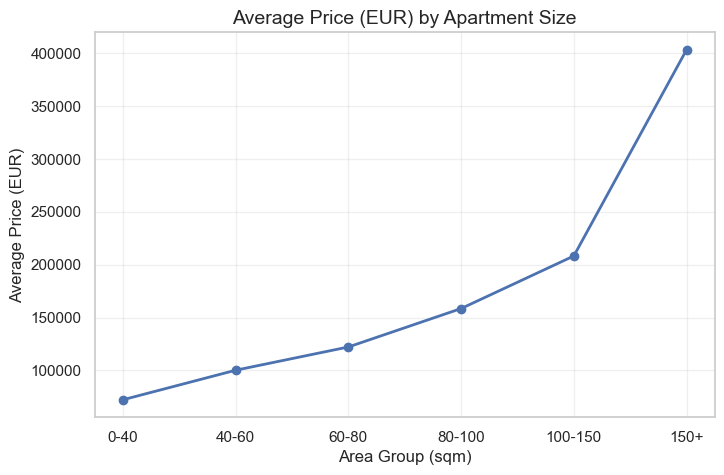

In [34]:
# Create area groups for simpler visualization
df_model["area_group"] = pd.cut(
    df_model["area_sqm"],
    bins=[0, 40, 60, 80, 100, 150, 300],
    labels=["0-40", "40-60", "60-80", "80-100", "100-150", "150+"]
)

# Calculate mean price for each group
area_mean = df_model.groupby("area_group")["price_eur"].mean().reset_index()

# Line chart
plt.figure(figsize=(8,5))
plt.plot(area_mean["area_group"], area_mean["price_eur"], marker="o", linewidth=2)
plt.title("Average Price (EUR) by Apartment Size", fontsize=14)
plt.xlabel("Area Group (sqm)", fontsize=12)
plt.ylabel("Average Price (EUR)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


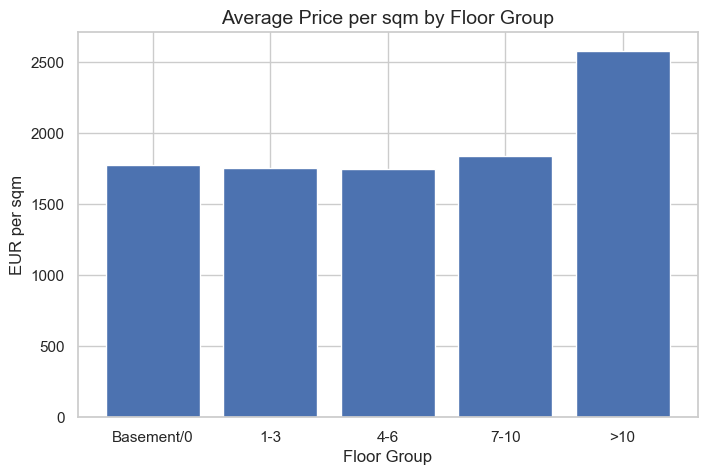

In [35]:
# If floor_group is not created yet:
df_model["floor_group"] = pd.cut(
    df_model["floor"],
    bins=[-2, 0, 3, 6, 10, 40],
    labels=["Basement/0", "1-3", "4-6", "7-10", ">10"]
)

# Calculate mean €/m² per floor group
floor_mean = df_model.groupby("floor_group")["price_per_sqm"].mean().reset_index()

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(floor_mean["floor_group"], floor_mean["price_per_sqm"])
plt.title("Average Price per sqm by Floor Group", fontsize=14)
plt.xlabel("Floor Group", fontsize=12)
plt.ylabel("EUR per sqm", fontsize=12)
plt.show()


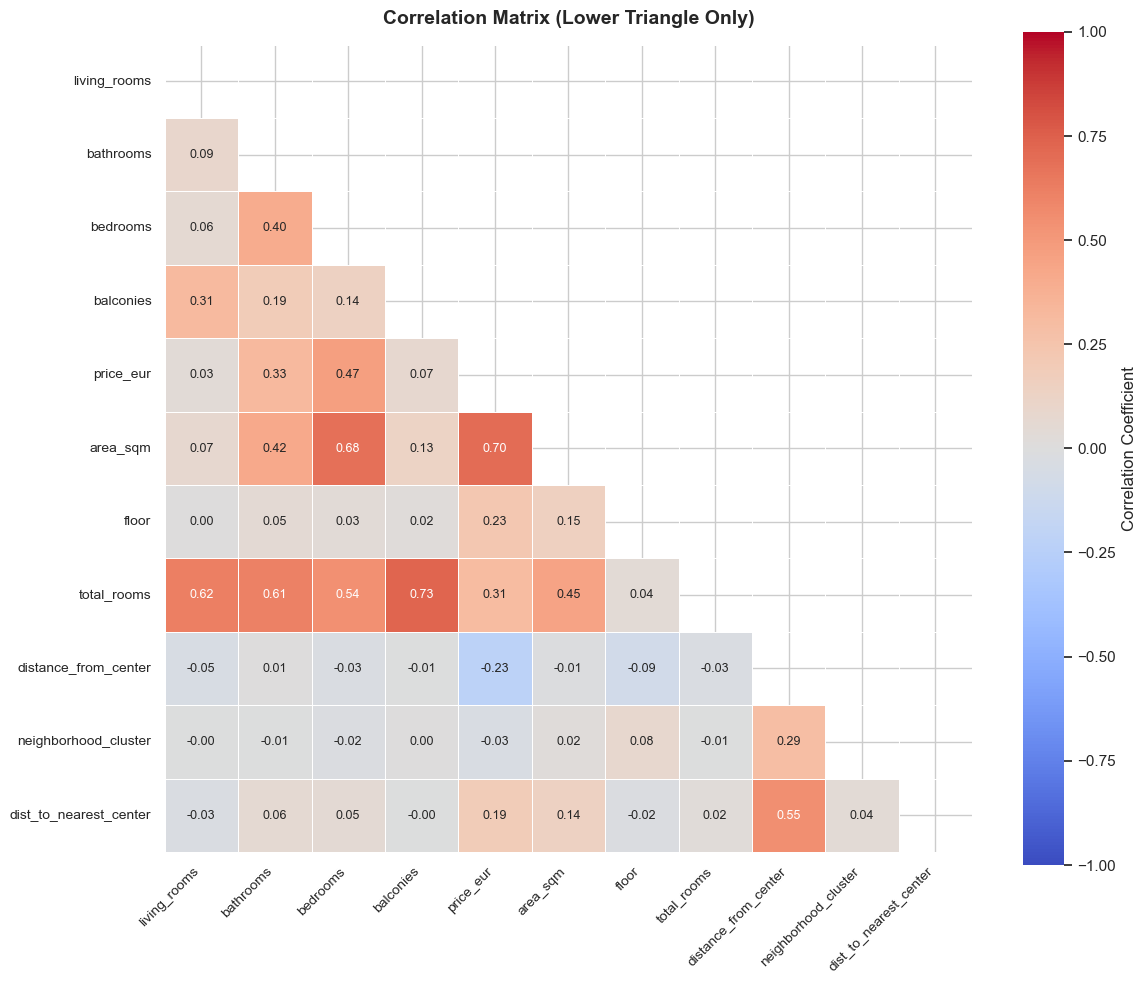

In [36]:
# ============================================================================
# RE-RUN CORRELATION ANALYSIS WITH NEW FEATURE
# ============================================================================

# Select numeric columns for correlation (excluding flags and derived columns)
numeric_cols = ['living_rooms', 'bathrooms', 'bedrooms', 'balconies', 'price_eur', 'area_sqm', 'floor', 
                'total_rooms', 'distance_from_center', 'neighborhood_cluster', 'dist_to_nearest_center']
numeric_cols = [col for col in numeric_cols if col in df_model.columns]

# Create correlation matrix
correlation_matrix = df_model[numeric_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"},
    annot_kws={"size": 9}
)

plt.title(
    "Correlation Matrix (Lower Triangle Only)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


## Encoding

In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical = [
    'area_sqm', 'floor', 'bedrooms', 'bathrooms', 'balconies', 'living_rooms',
    'has_elevator', 'has_parking_space', 'has_garage', 'has_carport', 'has_terrace', 'has_garden',
    'lat', 'lng', 'distance_from_center', 'dist_to_nearest_center', 'neighborhood_cluster', 'total_rooms'
]

categorical = ['furnishing_status', 'property_type', 'property_status']

# Drop columns not needed
drop = ['price_eur', 'description', 'price_currency']

# Validate all columns exist
missing = [c for c in numerical + categorical if c not in df_model.columns]
if missing:
    print(f"Warning: Missing columns {missing}")
    numerical = [c for c in numerical if c in df_model.columns]
    categorical = [c for c in categorical if c in df_model.columns]

print(f"Numerical features: {len(numerical)}")
print(f"Categorical features: {len(categorical)}\n")

# Preprocess
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), categorical)
    ],
    remainder='drop'
)

X = preprocessor.fit_transform(df_model)

# Get feature names
num_names = numerical
cat_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical))
all_features = num_names + cat_names

df_encoded = pd.DataFrame(X, columns=all_features)

print(f"Original: {df_model.shape}")
print(f"Encoded: {df_encoded.shape}")
print(f"\nEncoded features ({len(all_features)})")

Numerical features: 18
Categorical features: 3

Original: (4127, 26)
Encoded: (4127, 21)

Encoded features (21)


# TRAINING

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# ========================
# 1. SETUP DATA
# ========================
# Only use columns that exist in df_encoded
feature_cols = [
    'area_sqm', 'floor', 'bedrooms', 'bathrooms', 'has_elevator', 'has_parking_space', 'distance_from_center',
    'total_rooms', 'neighborhood_cluster', 'dist_to_nearest_center'
]

# Verify columns exist
feature_cols = [c for c in feature_cols if c in df_encoded.columns]
print(f"Using {len(feature_cols)} features\n")

X = df_encoded[feature_cols].copy()
y = df_model['price_eur'].copy()  # Use original y, not encoded

# Remove any NaN
mask = ~(X.isnull().any(axis=1) | y.isnull())
X = X[mask]
y = y[mask]

# ========================
# 2. TRAIN/TEST SPLIT
# ========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} | Test: {len(X_test)}\n")

# ========================
# 3. SCALING
# ========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[feature_cols])
X_test_scaled = scaler.transform(X_test[feature_cols])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

# ========================
# 4. MODELS
# ========================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

print("MODEL COMPARISON")
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross-val
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'CV R²': cv
    })
    
    print(f"{name}")
    print(f"  RMSE: €{rmse:,.0f} | MAE: €{mae:,.0f} | R²: {r2:.4f} | CV: {cv:.4f}\n")

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

Using 10 features

Train: 3301 | Test: 826

MODEL COMPARISON
Linear Regression
  RMSE: €72,753 | MAE: €51,030 | R²: 0.5794 | CV: 0.6368

Ridge (α=1.0)
  RMSE: €72,749 | MAE: €51,025 | R²: 0.5795 | CV: 0.6368

Lasso (α=0.1)
  RMSE: €72,753 | MAE: €51,030 | R²: 0.5794 | CV: 0.6368

KNN (k=5)
  RMSE: €54,467 | MAE: €35,808 | R²: 0.7643 | CV: 0.7483

Random Forest
  RMSE: €42,441 | MAE: €25,323 | R²: 0.8569 | CV: 0.8861

Gradient Boosting
  RMSE: €47,478 | MAE: €29,676 | R²: 0.8209 | CV: 0.8774

            Model         RMSE          MAE       R²    CV R²
    Random Forest 42440.769064 25322.803354 0.856880 0.886051
Gradient Boosting 47478.300148 29676.380471 0.820888 0.877411
        KNN (k=5) 54466.881979 35808.075424 0.764278 0.748340
    Ridge (α=1.0) 72748.785124 51024.711523 0.579480 0.636787
    Lasso (α=0.1) 72753.393854 51029.794146 0.579427 0.636777
Linear Regression 72753.402224 51029.839278 0.579427 0.636777


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Train best models
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

rf.fit(X_train_scaled, y_train)
gb.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

# ========================
# FEATURE IMPORTANCE
# ========================
print("="*80)
print("FEATURE IMPORTANCE")
print("="*80 + "\n")

# Random Forest
rf_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("RANDOM FOREST (Top 10)")
print("-"*80)
for i, row in rf_imp.head(10).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:25s} {bar} {row['importance']:.4f}")

# Gradient Boosting
gb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n\nGRADIENT BOOSTING (Top 10)")
print("-"*80)
for i, row in gb_imp.head(10).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:25s} {bar} {row['importance']:.4f}")

# XGBoost
xgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n\nXGBOOST (Top 10)")
print("-"*80)
for i, row in xgb_imp.head(10).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:25s} {bar} {row['importance']:.4f}")

# ========================
# MODEL COMPARISON
# ========================
print("\n\n" + "="*80)
print("XGBOOST vs OTHER MODELS")
print("="*80 + "\n")

models = {
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': f'€{rmse:,.0f}',
        'MAE': f'€{mae:,.0f}',
        'R²': f'{r2:.4f}'
    })
    
    print(f"{name}")
    print(f"  RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | R²: {r2:.4f}\n")


FEATURE IMPORTANCE

RANDOM FOREST (Top 10)
--------------------------------------------------------------------------------
area_sqm                  ████████████████████████████████████████████████████████ 0.5683
neighborhood_cluster      ██████████████████████ 0.2217
dist_to_nearest_center    ██████████ 0.1088
distance_from_center      ██████ 0.0627
floor                     █ 0.0163
total_rooms                0.0079
bedrooms                   0.0056
bathrooms                  0.0041
has_parking_space          0.0022
has_elevator               0.0022


GRADIENT BOOSTING (Top 10)
--------------------------------------------------------------------------------
area_sqm                  ██████████████████████████████████████████████████████████ 0.5813
neighborhood_cluster      ███████████████████████ 0.2399
dist_to_nearest_center    ████████ 0.0800
distance_from_center      ███████ 0.0749
floor                     █ 0.0105
bathrooms                  0.0076
has_parking_space          0.0